# NHC Wind Speed Probability Polygons

This notebook demonstrates how to use the WSP functions in `src/ocha_lens/datasources/nhc.py`.

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

import ocha_lens as lens

### 1. Load a single archived issuance

Pass an issuance timestamp (YYYYMMDDHH or ISO format) to fetch a specific file from the NHC GIS archive. The returned GeoDataFrame has one row per (wind threshold, probability band).

In [ ]:
# Hurricane Lee + Franklin active — 2023-08-22 00Z
gdf = lens.nhc.get_wsp(issued_time="2023082200")
print(
    f"{len(gdf)} rows — {gdf['issued_time'].nunique()} issuance, "
    f"{gdf['wind_threshold_kt'].nunique()} thresholds"
)
gdf.head()

### 2. Plot the avocado chart

Reproduce the NHC avocado plot for a single wind threshold.

In [3]:
WSP_COLORS = {
    0: "none",
    5: "#008B00",
    10: "#00CD00",
    20: "#7FFF00",
    30: "#FFFF00",
    40: "#FFD700",
    50: "#CD8500",
    60: "#FF7F00",
    70: "#CD0000",
    80: "#8B0000",
    90: "#8B008B",
}


def plot_avocado(gdf, wind_threshold_kt=34, title="", ax=None):
    subset = gdf[
        (gdf["wind_threshold_kt"] == wind_threshold_kt)
        & gdf["geometry"].notna()
    ].copy()
    subset["fill"] = subset["percentage"].map(WSP_COLORS)

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    ax.set_facecolor("#d0e8f0")
    for _, row in subset.iterrows():
        if row["fill"] == "none" or row["geometry"] is None:
            continue
        import geopandas as gpd

        gpd.GeoDataFrame([row], geometry="geometry", crs=gdf.crs).plot(
            ax=ax, color=row["fill"], edgecolor="none"
        )

    bounds = subset["geometry"].total_bounds
    pad = 5
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

    legend_labels = {
        0: "<5%",
        5: "5-10%",
        10: "10-20%",
        20: "20-30%",
        30: "30-40%",
        40: "40-50%",
        50: "50-60%",
        60: "60-70%",
        70: "70-80%",
        80: "80-90%",
        90: ">90%",
    }
    handles = [
        mpatches.Patch(
            facecolor=color,
            edgecolor="#888",
            linewidth=0.3,
            label=legend_labels[pct],
        )
        for pct, color in WSP_COLORS.items()
        if color != "none"
    ]
    ax.legend(
        handles=handles,
        title="Probability",
        loc="lower left",
        fontsize=7,
        title_fontsize=7,
    )

    kt_label = {
        34: "≥34 kt (TS-force)",
        50: "≥50 kt",
        64: "≥64 kt (Hurricane)",
    }
    ax.set_title(
        f"NHC 5-Day Wind Probability — {kt_label[wind_threshold_kt]}\n{title}",
        fontsize=10,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    return ax

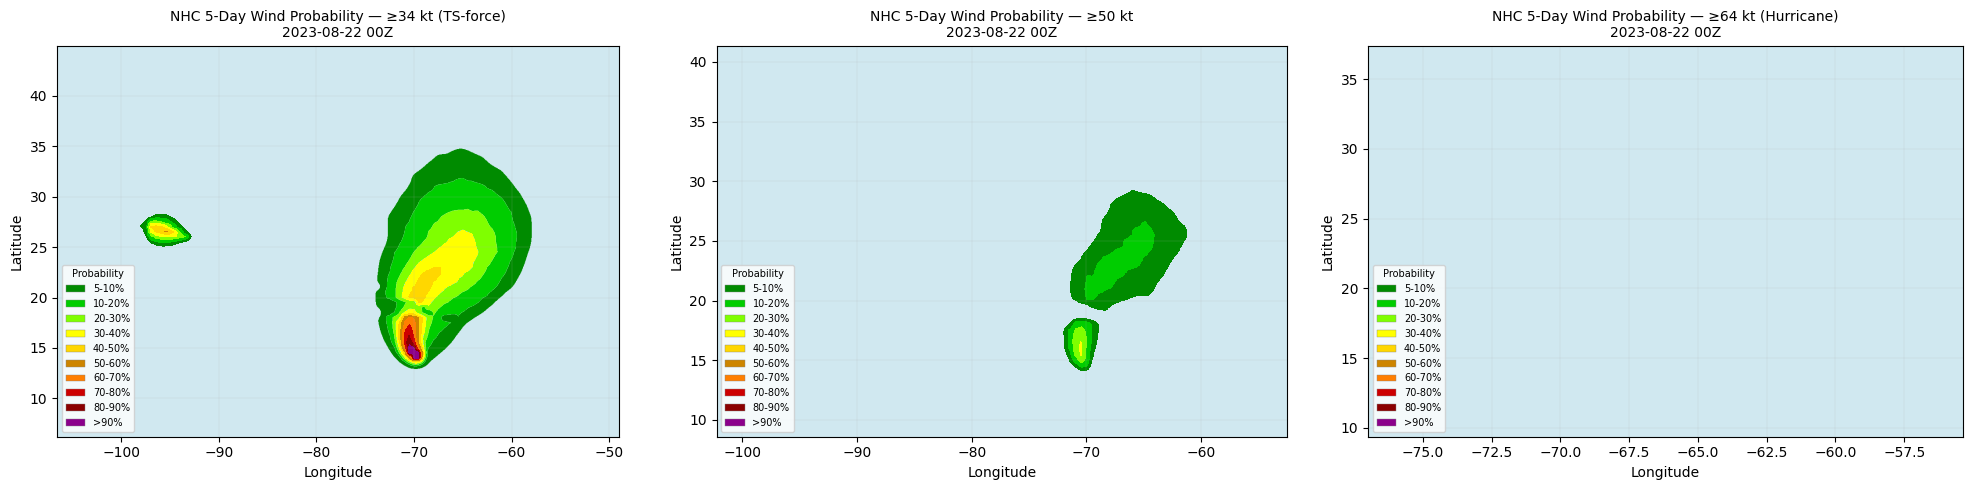

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
issuance_label = gdf["issued_time"].iloc[0].strftime("%Y-%m-%d %HZ")
for ax, kt in zip(axes, [34, 50, 64]):
    plot_avocado(gdf, wind_threshold_kt=kt, title=issuance_label, ax=ax)
plt.tight_layout()
plt.show()

### 3. Archive backfill

In [ ]:
# Fetch all issuances from the 2023 Atlantic hurricane season
gdf_season = lens.nhc.get_wsp(
    start="2023-11-15",
    end="2023-11-20",
    cache_dir="storm",
    use_cache=True,
)
print(
    f"{len(gdf_season)} rows across {gdf_season['issued_time'].nunique()} issuances"
)

### 4. Current mode (when storms are active)

In [ ]:
# Uncomment when storms are active
# gdf_current = lens.nhc.get_wsp()
# print(gdf_current["issued_time"].unique())